# Car Price Prediction — Model Training


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('Car Dataset Processed.csv')
print("Shape:", df.shape)
df.head(2)

Shape: (1499, 15)


,Unnamed: 0,car_name,registration_year,insurance_validity,fuel_type,seats,kms_driven,ownsership,transmission,manufacturing_year,mileage(kmpl),engine(cc),max_power(bhp),torque(Nm),price(in lakhs)
0,0,2017 Mercedes-Benz S-Class S400,Jul-17,Comprehensive,Petrol,5,56000,First Owner,Automatic,2017,7.81,2996.0,2996.0,333.0,63.75
1,1,2020 Nissan Magnite Turbo CVT XV Premium Opt BSVI,Jan-21,Comprehensive,Petrol,5,30615,First Owner,Automatic,2020,17.40,999.0,999.0,9863.0,8.99


## 1. Encode Categorical Features

In [7]:
d1 = {'Comprehensive': 0, 'Third Party insurance': 1, 'Third Party': 1, 'Zero Dep': 2, 'Not Available': 3}
d2 = {'Petrol': 0, 'Diesel': 1, 'CNG': 2}
d3 = {'First Owner': 1, 'Second Owner': 2, 'Third Owner': 3, 'Forth Owner': 4, 'Fifth Owner': 5}
d4 = {'Manual': 0, 'Automatic': 1}

df['insurance_validity'] = df['insurance_validity'].map(d1)
df['fuel_type']          = df['fuel_type'].map(d2)
df['ownsership']         = df['ownsership'].map(d3)
df['transmission']       = df['transmission'].map(d4)

print("Value counts — insurance_validity:")
print(df['insurance_validity'].value_counts())

Value counts — insurance_validity:
insurance_validity
0    1081
1     352
2      64
3       2
Name: count, dtype: int64


## 2. Remove Price Outliers (top 1%)

After outlier removal: (1484, 15)


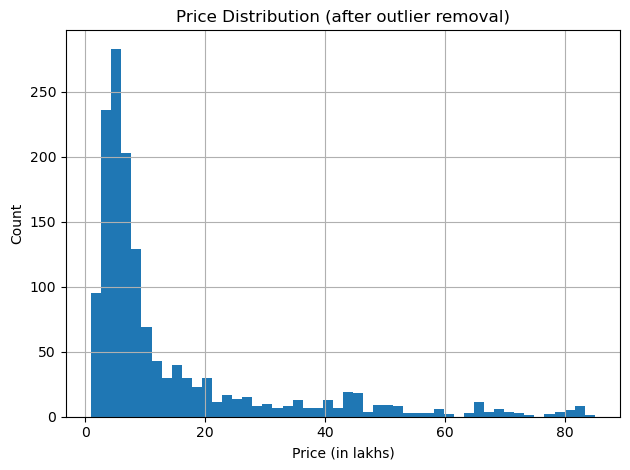

In [8]:
threshold = df['price(in lakhs)'].quantile(0.99)
df = df[df['price(in lakhs)'] < threshold]
print(f"After outlier removal: {df.shape}")
df['price(in lakhs)'].hist(bins=50)
plt.title('Price Distribution (after outlier removal)')
plt.xlabel('Price (in lakhs)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## 3. Feature Sets

In [9]:
FEATURES_ORIG = ['insurance_validity', 'fuel_type', 'kms_driven', 'ownsership', 'transmission']

FEATURES_EXT  = ['insurance_validity', 'fuel_type', 'kms_driven', 'ownsership', 'transmission',
                  'manufacturing_year', 'mileage(kmpl)', 'engine(cc)', 'max_power(bhp)', 'torque(Nm)', 'seats']

X_orig = df[FEATURES_ORIG]
X_ext  = df[FEATURES_EXT]
Y      = df['price(in lakhs)']

print("Original features:", X_orig.shape)
print("Extended features:", X_ext.shape)

Original features: (1484, 5)
Extended features: (1484, 11)


## 4. Model Comparison (Cross-Validation R²)

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score

models = {
    'LinearRegression':   LinearRegression(),
    'KNN-3':              KNeighborsRegressor(n_neighbors=3),
    'RandomForest':       RandomForestRegressor(n_estimators=100, random_state=42),
    'GradientBoosting':   GradientBoostingRegressor(n_estimators=100, random_state=42),
}

results = {}
print(f"{'Model':<22} {'Orig (5 feat)':>15} {'Ext (11 feat)':>15}")
print("-" * 55)
for name, model in models.items():
    s_orig = cross_val_score(model, X_orig, Y, cv=5, scoring='r2').mean()
    s_ext  = cross_val_score(model, X_ext,  Y, cv=5, scoring='r2').mean()
    results[name] = {'orig': s_orig, 'ext': s_ext}
    print(f"{name:<22} {s_orig:>15.4f} {s_ext:>15.4f}")

Model                    Orig (5 feat)   Ext (11 feat)
-------------------------------------------------------
LinearRegression                0.2020          0.2842
KNN-3                          -0.6109          0.2010
RandomForest                   -0.0026          0.6728
GradientBoosting                0.1566          0.6748


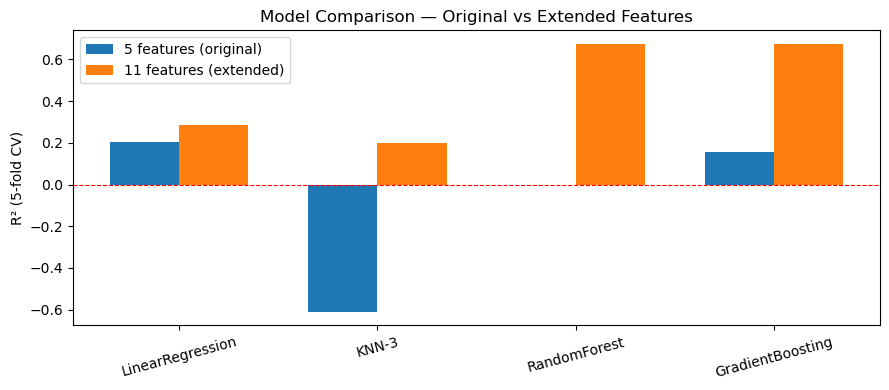

In [11]:
# Bar chart comparison
names = list(results.keys())
orig_scores = [results[n]['orig'] for n in names]
ext_scores  = [results[n]['ext']  for n in names]

x = np.arange(len(names))
w = 0.35
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - w/2, orig_scores, w, label='5 features (original)')
ax.bar(x + w/2, ext_scores,  w, label='11 features (extended)')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15)
ax.set_ylabel('R² (5-fold CV)')
ax.set_title('Model Comparison — Original vs Extended Features')
ax.axhline(0, color='red', linewidth=0.8, linestyle='--')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Train Best Model — Gradient Boosting (tuned)

In [12]:
best_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

scores = cross_val_score(best_model, X_ext, Y, cv=5, scoring='r2')
print(f"GBR Tuned — CV R²: {scores.mean():.4f} (+/- {scores.std():.4f})")

best_model.fit(X_ext, Y)
print("Model trained on full dataset.")

GBR Tuned — CV R²: 0.6699 (+/- 0.1169)
Model trained on full dataset.


## 6. Feature Importances

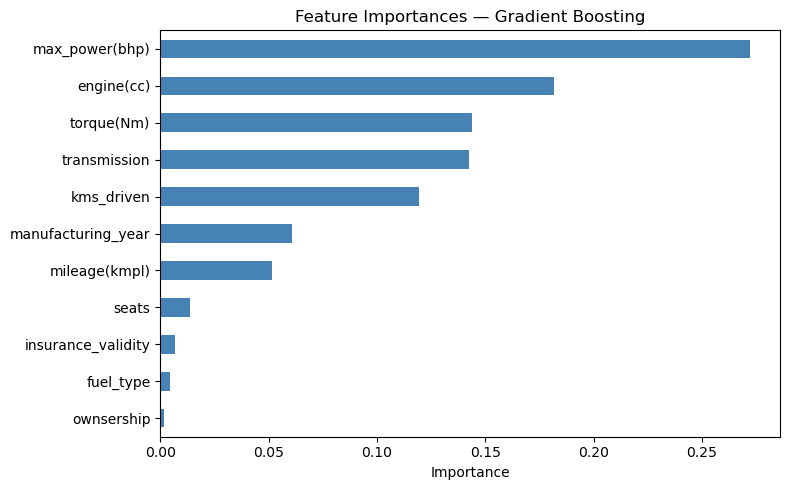

In [13]:
importances = best_model.feature_importances_
feat_imp = pd.Series(importances, index=FEATURES_EXT).sort_values(ascending=True)

feat_imp.plot(kind='barh', figsize=(8, 5), color='steelblue')
plt.title('Feature Importances — Gradient Boosting')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## 7. Save Model

In [14]:
import pickle
pickle.dump(best_model, open('model.pkl', 'wb'))
print("model.pkl saved successfully!")
print("Features used:", FEATURES_EXT)

model.pkl saved successfully!
Features used: ['insurance_validity', 'fuel_type', 'kms_driven', 'ownsership', 'transmission', 'manufacturing_year', 'mileage(kmpl)', 'engine(cc)', 'max_power(bhp)', 'torque(Nm)', 'seats']


## 8. Quick Prediction Test

In [15]:
sample = {
    'insurance_validity': d1['Comprehensive'],
    'fuel_type':          d2['Petrol'],
    'kms_driven':         40000,
    'ownsership':         d3['First Owner'],
    'transmission':       d4['Manual'],
    'manufacturing_year': 2019,
    'mileage(kmpl)':      18.5,
    'engine(cc)':         1500,
    'max_power(bhp)':     115,
    'torque(Nm)':         200,
    'seats':              5
}

test = [list(sample.values())]
pred = best_model.predict(test)[0]
print(f"Predicted price: ₹ {pred:.2f} Lakhs  (₹ {pred*100000:,.0f})")

Predicted price: ₹ 8.26 Lakhs  (₹ 825,581)
